![FaMAF-UNC](https://drive.google.com/uc?export=download&id=1k4tzcXOoq6TrkDEW_Ox8o4Y4pAHzKHb7
)
> Docentes: **Damián Fernández** y **Leandro Milne**
>> Teórico del 12-05-2021


# Integración múltiple

El concepto de integral de una función de una variable puede interpretarse como la superficie de la región limitada por el gráfico de la función en un intervalo. Veremos cómo generalizar este concepto cuando tenemos varias variables.




## Integrales iteradas

Suponga que tenemos $f:\mathbb{R}^2 \to  \mathbb{R}$ que está definida en un rectángulo $R=\{x\in\mathbb{R}^2 \mid x_1\in [a,b], \, x_2\in [c,d]\}$, que suele denotarse como $R=[a,b] \times [c,d]$. Luego
$$
    A(x_2) = \int_a^b f(x_1,x_2) dx_1,
$$
corresponde al área debajo de la curva $x_1 \mapsto f(x_1,x_2)$. De esta manera
$$
    \int_c^d A(x_2) dx_2 = \int_c^d\left( \int_a^b f(x_1,x_2) dx_1\right)dx_2,
$$
sería el volumen debajo de la superficie dada por el gráfico de $f$ y sobre el rectángulo $R$, y suele denotarse por
$$
    \int_R f(x) dx.
$$
Gráficamente, $A(x_2)$ es la intersección del sólido con el plano $\mathcal{P}=\{ y\in \mathbb{R}^3 \mid y_2=x_2\}$.



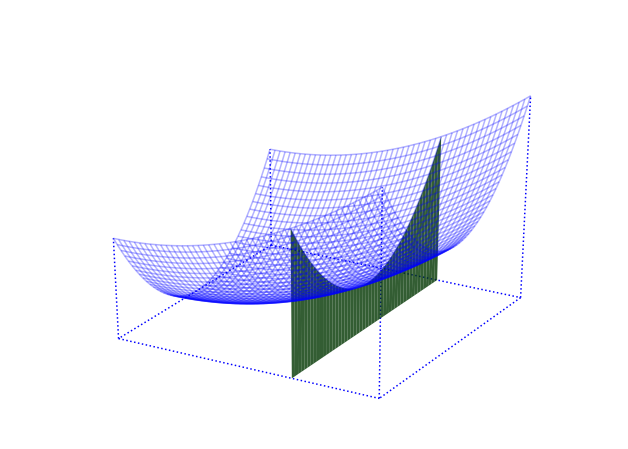

In [ ]:
#@title Cavalieri { display-mode: "form" }
x2 = 67 #@param {type:"slider", min:0, max:99, step:1}
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(1,1,1,projection='3d')

# ejes
#ax.plot3D([0,0],[-1.1,1.1], [0,0], color=(0.5,0.5,0.5))
#ax.plot3D([-1.1,1.1], [0,0], [0,0], color=(0.5,0.5,0.5))
#ax.plot3D([0,0], [0,0], [-1.1,1.1], color=(0.5,0.5,0.5))
# grilla
x, y = np.meshgrid(np.linspace(-1,1,50), np.linspace(0,1,50))
z = x**2 + y**2
# cuadratica
ax.plot_wireframe(x, y, z, color='b', alpha=0.3)
#ax.plot_surface(x, y, z, color='b', alpha=0.5)
# bordes
ax.plot3D(x[0,:],y[0,:], np.zeros(50), 'b:')
ax.plot3D(x[-1,:],y[-1,:], np.zeros(50), 'b:')
ax.plot3D(x[:,0],y[:,0], np.zeros(50), 'b:')
ax.plot3D(x[:,-1],y[:,-1], np.zeros(50), 'b:')
ax.plot3D([x[0,0], x[0,0]], [y[0,0], y[0,0]], [0, z[0,0]], 'b:')
ax.plot3D([x[0,-1], x[0,-1]], [y[0,-1], y[0,-1]], [0, z[0,-1]], 'b:')
ax.plot3D([x[-1,0], x[-1,0]], [y[-1,0], y[-1,0]], [0, z[-1,0]], 'b:')
ax.plot3D([x[-1,-1], x[-1,-1]], [y[-1,-1], y[-1,-1]], [0, z[-1,-1]], 'b:')
# plano
j = x2//2
#xp, yp = np.meshgrid([x[0,0],x[0,-1]],[y[j,0],y[j,0]])
#zp = xp**2 + yp**2
#zp[0,:]=0
xp = x[0:2,:]
yp = np.outer(np.ones(2),y[j,:])
zp = np.outer(np.array([1,0]),z[j,:])
ax.plot_surface(xp, yp, zp, color='g', alpha=0.8)


ax.view_init(30,30)
ax.axis('off');
#plt.savefig("cavalieri.pdf")


Este método para calcular volúmenes se conoce como principio de Cavalieri, que establece que el volumen de un cuerpo puede obtenerse integrando entre $a$ y $b$ una función $A:\mathbb{R} \to \mathbb{R}$ tal que $A(x)$ es el área de la sección transversal medida a una distancia $x$ de un plano de referencia, donde $a$ y $b$ son las distancias mínima y máxima a partir del plano de referencia.


Una aplicación directa del principio de Cavalieri se consigue al calcular el volumen de un sólido de revolución $B$, esto es, el gráfico de una función $f:[a,b] \to \mathbb{R}$ rotado alrededor del eje $x_1$.





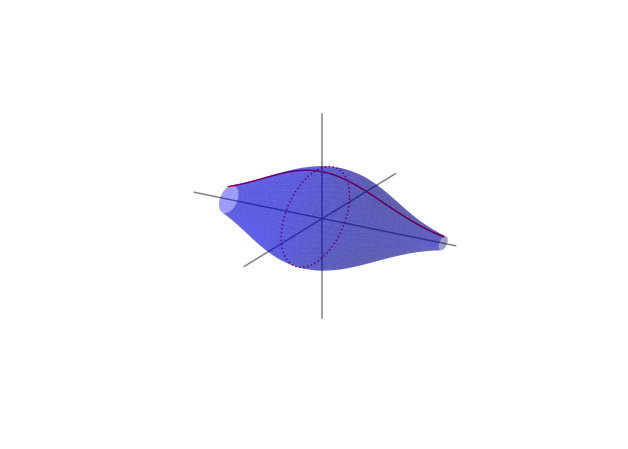

In [ ]:
#@title Sólido de revolución { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(1,1,1,projection='3d')

# ejes
ax.plot3D([0,0],[-1.1,1.1], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([-1.1,1.1], [0,0], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [0,0], [-1.1,1.1], color=(0.5,0.5,0.5))
# grilla
th = np.linspace(0, 2*np.pi, 50)
t = np.linspace(-0.8, 1, 30)
f = 0.5*np.exp(-t**2/0.5)
x = np.outer(t, np.ones(th.shape))
y = np.outer(f, np.cos(th))
z = np.outer(f, np.sin(th))
ax.plot_surface(x, y, z, color='b', alpha=0.4)
i = 12
#ax.plot3D(x, np.zeros(x.shape), -f, color='r')
ax.plot3D(t, np.zeros(t.shape), f, color='r')
ax.plot3D(x[i,:], y[i,:], z[i,:], 'r:')
#ax.view_init(30,30)
ax.axis('off');
#plt.savefig("solidorevolucion.pdf")


Para cada $t\in [a,b]$ tomemos $A(t)$ como el área de la intersección de $B$ con el plano $x_1=t$, que es el disco con centro cero y radio $f(t)$. Por lo tanto $A(t)=\pi (f(t))^2$. Luego el volumen de $B$ es
$$
    \int_a^b A(t) dt = \int_a^b \pi (f(t))^2 dt.
$$


#### Ejemplo

Sea desea calcular el volumen bajo el gráfico de $f:\mathbb{R}^2 \to \mathbb{R}$ tal que $f(x) = x_1^2 + x_2$ y sobre el rectángulo $R=[0,1] \times [1,2]$.

Si tomamos como referencia el plano $\mathcal{P}=\{ x\in \mathbb{R}^3 \mid x_2=0\}$ tenemos que
\begin{align*}
 \int_1^2 \left( \int_{0}^1 (x_1^2 + x_2) dx_1 \right) dx_2
        &= \int_1^2 \left[ \frac{1}{3}x_1^3 + x_1 x_2\right]_{x_1=0}^{x_1=1} dx_2
        = \int_1^2 \left( \frac{1}{3} + x_2\right) dx_2\\
        &= \left[ \frac{1}{3}x_2 + \frac{1}{2}x_2^2 \right]_{x_2=1}^{x_2=2}
        = \frac{1}{3} + \frac{3}{2} = \frac{11}{6}.
\end{align*}

Si tomamos como referencia el plano $\mathcal{P}=\{ x\in \mathbb{R}^3 \mid x_1=0\}$ tenemos que
\begin{align*}
 \int_0^1 \left( \int_1^2 (x_1^2 + x_2) dx_2 \right) dx_1
        &= \int_0^1 \left[ x_1^2 x_2 + \frac{1}{2} x_2^2\right]_{x_2=1}^{x_2=2} dx_1
        = \int_0^1 \left( x_1^2 + \frac{3}{2} \right) dx_1\\
        &= \left[ \frac{1}{3}x_1^3 + \frac{3}{2}x_1 \right]_{x_1=0}^{x_1=1}
        = \frac{1}{3} + \frac{3}{2} = \frac{11}{6}.
\end{align*}

Demostrando de esta manera que
$$
    \int_R f(x) dx = \frac{11}{6}.
$$


Luego veremos en qué circunstancias el resultado de la integración iterada es independiente del orden de integración.


Si denotamos por $|R|$ al área de un rectángulo, claramente este valor concide con el volumen bajo el gráfico de la función $f(x)=1$ para todo $x$. Pues, si $R=[a,b]\times [c,d]$,
$$
 \int_R 1 dx = \int_c^d \int_a^b 1 dx_1 dx_2 = \int_c^d (b-a) dx_2 = (b-a)(d-c) = |R|.
$$



Por lo tanto, el área del primer cuadrante del disco unitario
$$
C=\left\{x\in \mathbb{R}^2 \mid 0\leq x_1 \leq 1, \, 0\leq x_2 \leq \sqrt{1-x_1^2}\right\},
$$
puede escribirse como
\begin{align*}
    |C| &= \int_0^1 \int_0^{\sqrt{1-x_1^2}} 1 dx_2 dx_1 = \int_0^1 \sqrt{1-x_1^2} dx_1 \\
      &=\left[ \frac{1}{2}x_1 \sqrt{1-x_1^2} - \frac{1}{2}\arccos(x_1) \right]_0^1
      = \frac{\pi}{4}.
\end{align*}
Note que si en vez de integrar la función idénticamente uno deseamos hallar el volumen bajo el gráfico de $f:\mathbb{R}^2 \to \mathbb{R}$ sobre el conjunto $C$, se procede de manera análoga a lo realizado con el rectángulo, obteniendo que dicho volumen es
$$
    \int_C f(x) dx = \int_0^1 \int_0^{\sqrt{1-x_1^2}} f(x_1,x_2) dx_2 dx_1.
$$



En general si $D=\{ x\in\mathbb{R}^2 \mid a \leq x_1 \leq b, \, \eta_1(x_1) \leq x_2 \leq \eta_2(x_1)\}$, para funciones $\eta_i:[a,b] \to \mathbb{R}$ tal que $\eta_1(t) \leq \eta_2(t)$ para todo $t\in[a,b]$, entonces
$$
    \int_D f(x) dx = \int_a^b \int_{\eta_1(x_1)}^{\eta_2(x_1)} f(x_1,x_2) dx_2 dx_1.
$$
Si $D=\{ x\in\mathbb{R}^2 \mid c \leq x_2 \leq d, \, \xi_1(x_2) \leq x_1 \leq \xi_2(x_2)\}$, para funciones $\xi_i:[c,d] \to \mathbb{R}$ tal que $\xi_1(t) \leq \xi_2(t)$ para todo $t\in[c,d]$, entonces
$$
    \int_D f(x) dx = \int_c^d \int_{\xi_1(x_2)}^{\xi_2(x_2)} f(x_1,x_2) dx_1 dx_2.
$$
Claramente, si $D$ puede expresarse de ambas maneras entonces las integrales anteriores serán iguales.




Con este mismo razonamiento, para calcular el volumen de
$$
B=\{x\in \mathbb{R}^3 \mid 0\leq x_1 \leq 1, \, x_1^2 \leq x_2 \leq x_1 , \, x_1 \leq x_3 \leq 2x_1 + x_2 \},
$$
que denotaremos por $|B|$, tenemos que
\begin{align*}
    |B|
    &=\int_0^1 \int_{x_1^2}^{x_1} \int_{x_1}^{2x_1 + x_2} 1 dx_3 dx_2 dx_1
    = \int_0^1 \left(\int_{x_1^2}^{x_1} (x_1 + x_2) dx_2 \right)dx_1\\
    &=\int_0^1 \left[x_1 x_2 + \frac{1}{2}x_2^2 \right]_{x_2=x_1^2}^{x_2=x_1} dx_1
    =\int_0^1 \left( x_1 (x_1-x_1^2) + \frac{1}{2}(x_1^2-x_1^4) \right) dx_1\\
    &= \left[ \frac{1}{2}x_1^3  - \frac{1}{4} x_1^4  - \frac{1}{10}x_1^5 \right]_0^1
    = \frac{1}{2}  - \frac{1}{4}  - \frac{1}{10} = \frac{3}{20}
\end{align*}


De esta manera, suponga que se tiene el conjunto
$$
    D = \{x\in \mathbb{R}^n \mid 0\leq x_n \leq x_{n-1} \leq \ldots \leq x_2 \leq x_1 \leq 1\},
$$
y se desea obtener su medida $n$-dimensional $|D|$. Para ello, podemos ver que
\begin{align*}
    |D| &= \int_0^1 \int_0^{x_1} \ldots \int_0^{x_{n-1}} 1 dx_n \ldots dx_2 dx_1 \\
        &= \int_0^1 \int_0^{x_1} \ldots \int_0^{x_{n-2}} x_{n-1} dx_{n-1} \ldots dx_2 dx_1 \\
        &= \int_0^1 \int_0^{x_1} \ldots \int_0^{x_{n-3}} \frac{1}{2} x_{n-2}^2 dx_{n-2} \ldots dx_2 dx_1\\
        &= \int_0^1 \int_0^{x_1} \ldots \int_0^{x_{n-4}} \frac{1}{3!} x_{n-3}^3 dx_{n-3} \ldots dx_2 dx_1\\
        &= \ldots =  \int_0^1 \frac{1}{(n-1)!} x_{1}^{n-1} dx_1 = \frac{1}{n!}.
\end{align*}



Para justificar las operaciones realizadas con integrales, deberemos especificar para qué tipo de funciones y conjuntos las mismas son válidas.

Considere el hiperrectángulo cerrado en $\mathbb{R}^n$
$$
    R=\{x\in \mathbb{R}^n \mid a_i \leq x_i \leq b_i, \, i=1,\ldots,n\}.
$$
Si todos los $\leq$ de la definición son cambiados por $<$ diremos que el hiperrectángulo es abierto, y si sólo algunos de los $\leq$ son cambiados diremos simplemente que se trata de un hiperrectángulo.
El volumen generalizado o **medida** de $R$ (cerrado, abierto o general) se define como
$$
    |R| = (b_1-a_1)(b_2-a_2) \ldots (b_n-a_n).
$$
Si para algún $i$ se tiene $a_i=b_i$, entonces $|R|=0$ y diremos que tiene medida nula.

Para entender este concepto, note que en $\mathbb{R}^1$ tendríamos que $R$ es el intervalo $[a_1, b_1]$ y su medida $|R|=b_1-a_1$ es su longitud. En $\mathbb{R}^2$ tendríamos que $R$ es el rectángulo $[a_1, b_1]\times [a_2,b_2]$ y su medida $|R|=(b_1-a_1)(b_2-a_2)$ es su superficie. En $\mathbb{R}^3$ tendríamos que $R$ es el paralelepípedo rectangular $[a_1, b_1]\times [a_2,b_2]\times [a_3,b_3]$ y su medida $|R|=(b_1-a_1)(b_2-a_2)(b_3-a_3)$ es su volumen.
Además, si $R=[a_1, b_1]\times [a_2,b_2]\times \{a_3\}$, entonces $R$ es un rectángulo en un espacio tridimensional y por lo tanto su volumen (medida en $\mathbb{R}^3$) es cero.

Suponga que el conjunto donde se desea integrar $D\subset \mathbb{R}^n$ es acotado. Tomando una cantidad finita de hiperplanos ortogonales a los ejes coordenados, generamos una grilla en $\mathbb{R}^n$ que nos define los hiperrectángulos acotados $R_1, \ldots R_p$ que cubren $D$, o sea $D \subset \cup_{i=1}^p R_i$. A este cubrimiento $\mathcal{G} = \{R_1, \ldots, R_p\}$ le asociamos el número $m(\mathcal{G})$, llamado longitud del cubrimiento, que es igual al máximo de las longitudes de los ejes de los elementos del cubrimiento.

Suponga ahora que la función que se desea integrar $f:\mathbb{R}^n \to \mathbb{R}$ es acotadas sobre $D$, o sea, el conjunto
$$
    f(D) = \{ y\in \mathbb{R}  \mid y=f(x) \textrm{ para algún } x\in D\},
$$
es acotado. Entonces para cualquier cubrimiento  $\mathcal{G} = \{R_1, \ldots, R_p\}$, tomando puntos arbitrarios $x^i \in R_i \cap D$, definimos la suma de Riemann de $f$ sobre $D$ como
$$
    \sum_{i=1}^p f(x^i) |R_i|.
$$



>**Definición**
>
> Diremos que $f$ es integrable sobre $D$ si
$$
 \lim_{m(\mathcal{G}) \to 0}   \sum_{i=1}^p f(x^i) |R_i|,
$$
existe y es igual para cualquier selección de puntos $x^i$. En este caso denotaremos tal límite como
$$
 \int_D f(x) dx.
$$



Existen muchas notaciones distintas en la literatura para esta integral. Entre ellas, para $n=2$ algunas son
$$
    \int_D f dA, \quad \int_D f(x_1,x_2) dx_1 dx_2, \quad \iint_D f(x_1,x_2) dx_1 dx_2,
$$
y para $n=3$
$$
    \int_D f dV, \quad \int_D f(x_1,x_2,x_3) dx_1 dx_2 dx_3, \quad \iiint_D f(x_1,x_2, x_3) dx_1 dx_2 dx_3.
$$




Cuando se integra en una variable, se sabe que si a la región de integración se la modifica en un punto o una cantidad finita de puntos, entonces el resultado de la integral no se altera. Esto puede justificarse porque son conjuntos de medida unidimensional nula.

Para generalizar esto, diremos que un **conjunto suave** en $\mathbb{R}^n$ es aquel definido como la imagen de un conjunto cerrado y acotado dada por una función continuamente diferenciable $\phi:\mathbb{R}^m \to \mathbb{R}^n$ con $m<n$.
Por ejemplo, para $n=3$ si $m=1$ tendremos una curva y si $m=2$ tendremos una superficie. Ambos conjuntos tienen medida tridimensional nula. Además, un conjunto suave en $\mathbb{R}$ es simplemente un punto.

La demostración del siguiente resultado puede verlo en el Apéndice del libro de Williamson-Crowell-Trotter.


> **Teorema**
>
>Sea $f:\mathbb{R}^n \to \mathbb{R}$ definida y acotada sobre el conjunto acotado $D\subset \mathbb{R}^n$, tal que la frontera de $D$ esté contenida en una cantidad finita de conjuntos suaves. Si $f$ es continua en $D$ excepto quizás en una cantidad finita de conjuntos suaves, entonces $f$ es integrable sobre $D$ y la integral $\int_D f(x) dx$ es independiente de los valores de $f$ sobre cualquier conjunto suave.



La clase que viene veremos cuándo se puede cambiar el orden de integración.

---

---